In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [41]:
df = pd.read_csv("telecom_customer_churn.csv")
print("✔ Dataset Loaded Successfully!")

✔ Dataset Loaded Successfully!


In [42]:
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 7043
Total Columns: 38


In [43]:
print("\nColumn Names: \n", df.columns.tolist())


Column Names: 
 ['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason']


In [44]:
print("\n--- FIRST 5 ROWS ---")
print(df.head())


--- FIRST 5 ROWS ---
  Customer ID  Gender  Age Married  Number of Dependents          City  \
0  0002-ORFBO  Female   37     Yes                     0  Frazier Park   
1  0003-MKNFE    Male   46      No                     0      Glendale   
2  0004-TLHLJ    Male   50      No                     0    Costa Mesa   
3  0011-IGKFF    Male   78     Yes                     0      Martinez   
4  0013-EXCHZ  Female   75     Yes                     0     Camarillo   

   Zip Code   Latitude   Longitude  Number of Referrals  ...   Payment Method  \
0     93225  34.827662 -118.999073                    2  ...      Credit Card   
1     91206  34.162515 -118.203869                    0  ...      Credit Card   
2     92627  33.645672 -117.922613                    0  ...  Bank Withdrawal   
3     94553  38.014457 -122.115432                    1  ...  Bank Withdrawal   
4     93010  34.227846 -119.079903                    3  ...      Credit Card   

  Monthly Charge Total Charges  Total Refunds 

In [45]:
print("\n--- DATA INFO ---")
print(df.info())


--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              31

In [46]:
print("\n--- SUMMARY STATISTICS ---")
print(df.describe())


--- SUMMARY STATISTICS ---
               Age  Number of Dependents      Zip Code     Latitude  \
count  7043.000000           7043.000000   7043.000000  7043.000000   
mean     46.509726              0.468692  93486.070567    36.197455   
std      16.750352              0.962802   1856.767505     2.468929   
min      19.000000              0.000000  90001.000000    32.555828   
25%      32.000000              0.000000  92101.000000    33.990646   
50%      46.000000              0.000000  93518.000000    36.205465   
75%      60.000000              0.000000  95329.000000    38.161321   
max      80.000000              9.000000  96150.000000    41.962127   

         Longitude  Number of Referrals  Tenure in Months  \
count  7043.000000          7043.000000       7043.000000   
mean   -119.756684             1.951867         32.386767   
std       2.154425             3.001199         24.542061   
min    -124.301372             0.000000          1.000000   
25%    -121.788090         

In [47]:
# --- Visualize Missing Values (for Selected Columns Only) ---
# Select a few important columns for a clear heatmap view
selected_columns = [
    'Customer ID',
    'Gender',
    'Age',
    'Married',
    'Tenure in Months',
    'Internet Service',
    'Avg Monthly Long Distance Charges',
    'Online Security',
    'Churn Category'
]

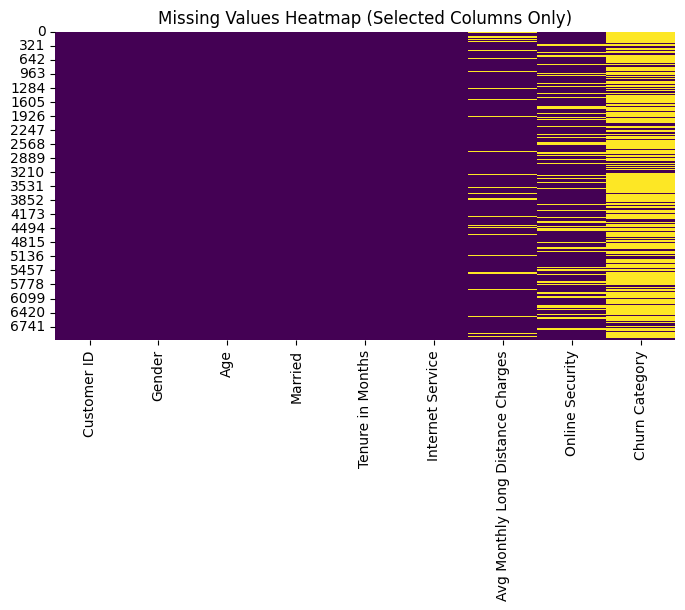

In [48]:
# Keep only columns that actually exist in the dataset
selected_columns = [col for col in selected_columns if col in df.columns]

# Plot heatmap for these selected columns only
plt.figure(figsize=(8, 4))
sns.heatmap(df[selected_columns].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Selected Columns Only)")
plt.show()

In [49]:
missing_before = df.isnull().sum()
print("\nMissing Values Before:\n", missing_before[missing_before > 0])


Missing Values Before:
 Offer                                3877
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                     1526
Streaming Music                      1526
Unlimited Data                       1526
Churn Category                       5174
Churn Reason                         5174
dtype: int64


In [50]:
# Fill numeric columns with mean, categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_28832\2457233951.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_28832\2457233951.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

In [51]:
missing_after = df.isnull().sum()
print("\nMissing Values After:\n", missing_after[missing_after > 0])


Missing Values After:
 Series([], dtype: int64)


In [52]:
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Records Before: {duplicates}")


Number of Duplicate Records Before: 0


In [53]:
df.drop_duplicates(inplace=True)
print(f"Number of Duplicate Records After: {df.duplicated().sum()}")

Number of Duplicate Records After: 0


In [54]:
# Example: Standardize Gender column
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].str.strip().str.title()
    # The PDF code's replace logic was a bit redundant if .title() is used
    # This is a cleaner way to get 'Female' and 'Male'
    
print("\nUnique Values in Gender Column:\n", df['Gender'].unique())


Unique Values in Gender Column:
 ['Female' 'Male']


In [55]:
# Example: Convert 'Tenure in Months' to integer
if 'Tenure in Months' in df.columns:
    df['Tenure in Months'] = df['Tenure in Months'].astype(int)

print("\nData Types After Conversion (Head):\n", df.dtypes.head())


Data Types After Conversion (Head):
 Customer ID             object
Gender                  object
Age                      int64
Married                 object
Number of Dependents     int64
dtype: object


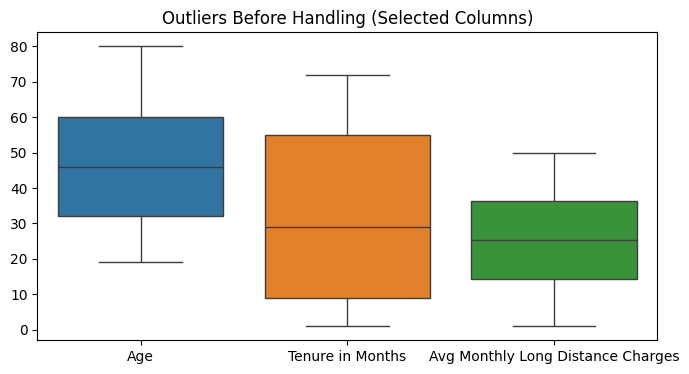

In [56]:
# Limit to a few important numeric columns for clear plot
sample_cols = ['Age', 'Tenure in Months', 'Avg Monthly Long Distance Charges']
sample_cols = [col for col in sample_cols if col in df.columns]

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[sample_cols])
plt.title("Outliers Before Handling (Selected Columns)")
plt.show()

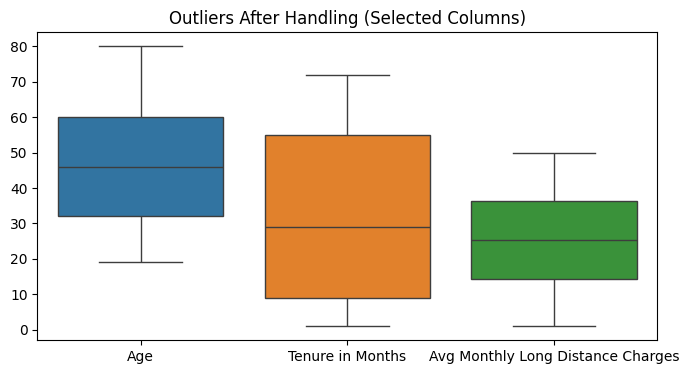

In [57]:
# Remove outliers using IQR for these columns only
for col in sample_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    
    # Filter the dataframe
    df = df[(df[col] >= lower) & (df[col] <= upper)]

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[sample_cols])
plt.title("Outliers After Handling (Selected Columns)")
plt.show()

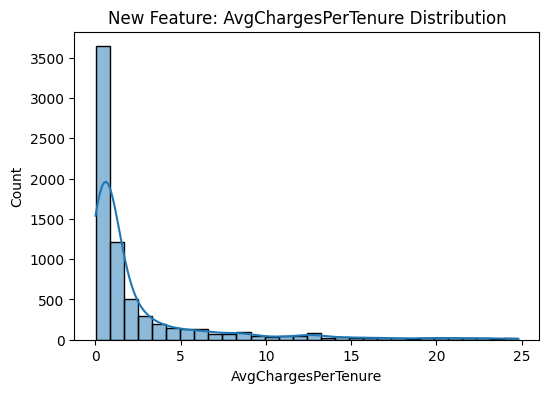

In [58]:
# Example: Create 'AverageChargesPerTenure'
if 'Avg Monthly Long Distance Charges' in df.columns and 'Tenure in Months' in df.columns:
    # Add 1 to Tenure to avoid division by zero
    df['AvgChargesPerTenure'] = df['Avg Monthly Long Distance Charges'] / (df['Tenure in Months'] + 1)
    
    plt.figure(figsize=(6, 4))
    sns.histplot(df['AvgChargesPerTenure'], bins=30, kde=True)
    plt.title("New Feature: AvgChargesPerTenure Distribution")
    plt.show()

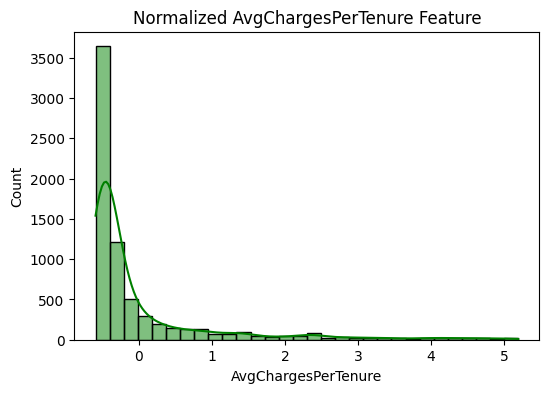

In [59]:
scaler = StandardScaler()
scaled_cols = ['Avg Monthly Long Distance Charges', 'Tenure in Months', 'AvgChargesPerTenure']
scaled_cols = [c for c in scaled_cols if c in df.columns]

if scaled_cols:
    df[scaled_cols] = scaler.fit_transform(df[scaled_cols])
    
    # Plot one of the normalized features
    plt.figure(figsize=(6, 4))
    sns.histplot(df['AvgChargesPerTenure'], bins=30, kde=True, color='green')
    plt.title("Normalized AvgChargesPerTenure Feature")
    plt.show()

In [60]:
target_col = 'Churn Category' if 'Churn Category' in df.columns else 'Customer Status'
X = df.drop(columns=[target_col], errors='ignore')
y = df[target_col] if target_col in df.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\n✔ Dataset Split Done: \nTraining Rows: {X_train.shape[0]}, Testing Rows: {X_test.shape[0]}")
else:
    print("\nTarget column not found. Could not split dataset.")


✔ Dataset Split Done: 
Training Rows: 5634, Testing Rows: 1409


In [61]:
df.to_csv("Telecom_Customer_Churn_Cleaned.csv", index=False)
print("\n✔ Cleaned Dataset Saved as 'Telecom_Customer_Churn_Cleaned.csv'")


✔ Cleaned Dataset Saved as 'Telecom_Customer_Churn_Cleaned.csv'
